#notes
to control overfitting we have 3 methods
1. CV cross validation
2.  regularisation(ridge lasso, elastiocnet
3. PCA
4. ensemble techniques(bagging and boosting?)

DT
1. Root nodes
2. descision nodes
3. terminal nodes


ensenble techniques: combination of results
bagging is a parallel mechanism. boosting is sequential mechanism.

bagging technique we take n no of samples from one sample and train all the models parallelly.


base stimator: DT7LT7SVC
n estimator: 50,100,150,200

Ín random forest there is no n estimator


##BOOSTING
IS SEQUENTIAL. boosting we are interested in errors


there are three nechanism in Boosting
1. Gradient Boosting
2. Ada bOOSTING8Adaptive boosting)
3. XGBoost

GridsearchCV


LGBM & XGBM  
Objective:  
The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the diabetes dataset.   
Exploratory Data Analysis (EDA):  
1.	Load the Titanic dataset using Python's pandas library.  
2.	Check for missing values.    
3.	Explore data distributions using histograms and box plots.  
4.	Visualize relationships between features and survival using scatter plots and bar plots.  
Data Preprocessing:  
1.	Impute missing values.  
2.	Encode categorical variables using one-hot encoding or label encoding.   
3.	If needed you can apply more preprocessing methods on the given dataset.    
Building Predictive Models:  
1.	Split the preprocessed dataset into training and testing sets.  
2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.  
3.	Build predictive models using LightGBM and XGBoost algorithms.  
4.	Train the models on the training set and evaluate their performance on the testing set.   
5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.  
Comparative Analysis:  
1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.  
2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.  
Submission Requirements:  
Well-commented code explaining each step of the analysis.  
Visualizations with appropriate titles and labels.  
A brief report summarizing the comparative analysis results and practical implications.  



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
df=pd.read_csv('/content/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.size

6912

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# Replace impossible zero values with NaN
columns = ["Glucose","BloodPressure","SkinThickness",
           "Insulin","BMI"]

df[columns] = df[columns].replace(0, np.nan)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df['BloodPressure'].fillna(df['BloodPressure'].mean(), inplace=True)
df['SkinThickness'].fillna(df['SkinThickness'].median(), inplace=True)
df['Insulin'].fillna(df['Insulin'].median(), inplace=True)
df['BMI'].fillna(df['BMI'].median(), inplace=True)

/tmp/ipykernel_3838/1028154158.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BloodPressure'].fillna(df['BloodPressure'].mean(), inplace=True)
/tmp/ipykernel_3838/1028154158.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


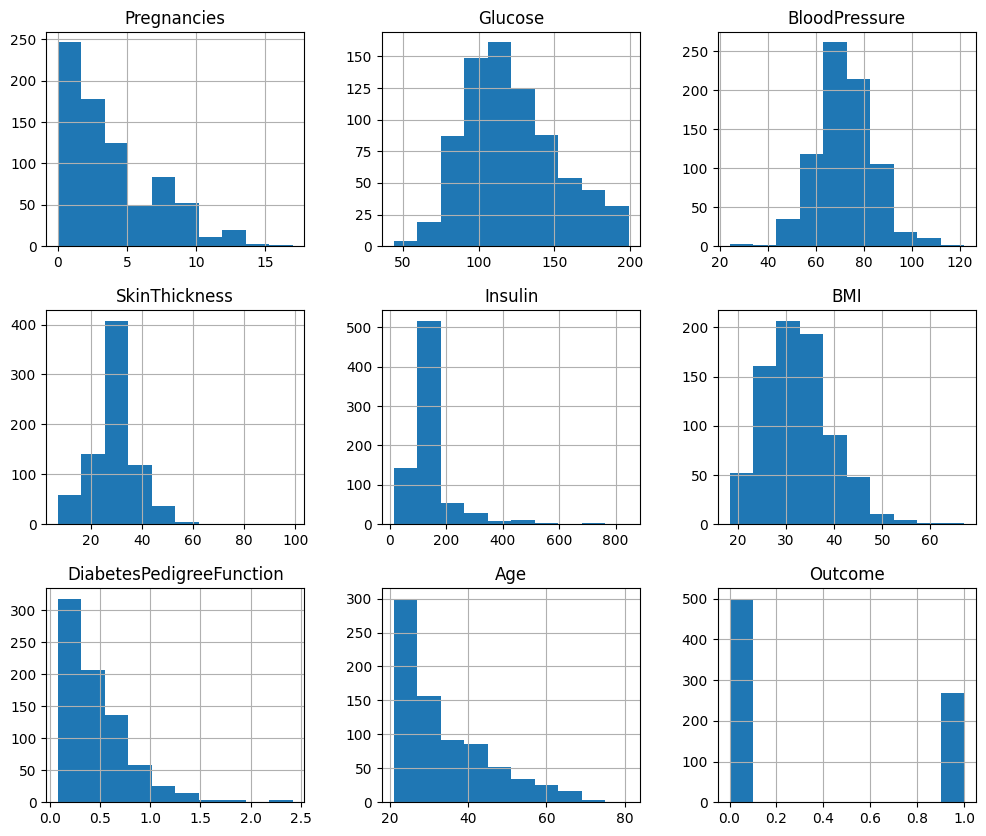

In [ ]:
df.hist(figsize=(12,10))
plt.show()

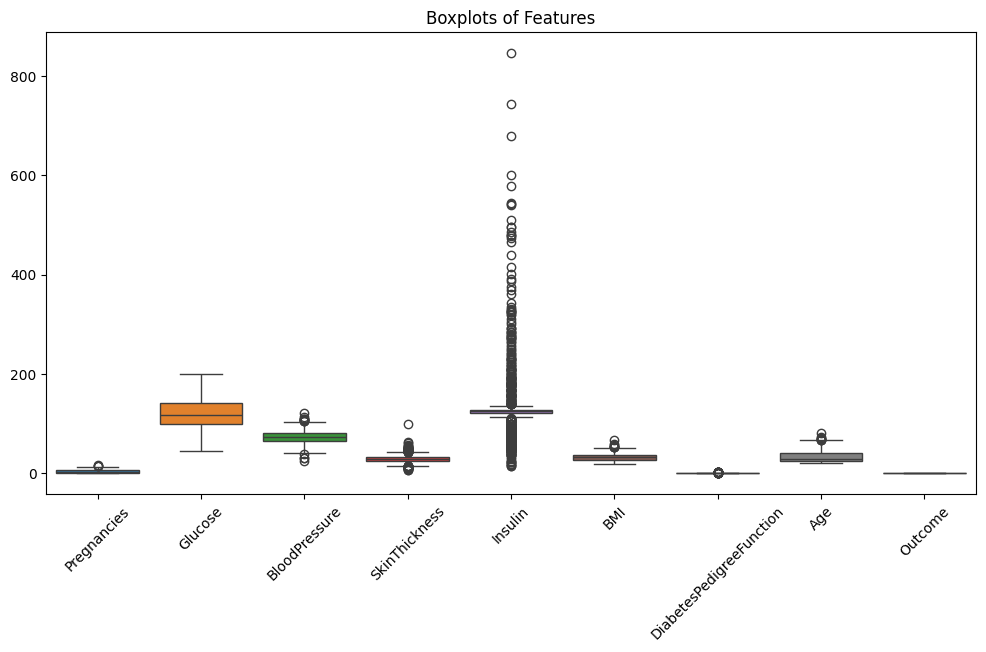

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplots of Features")
plt.show()

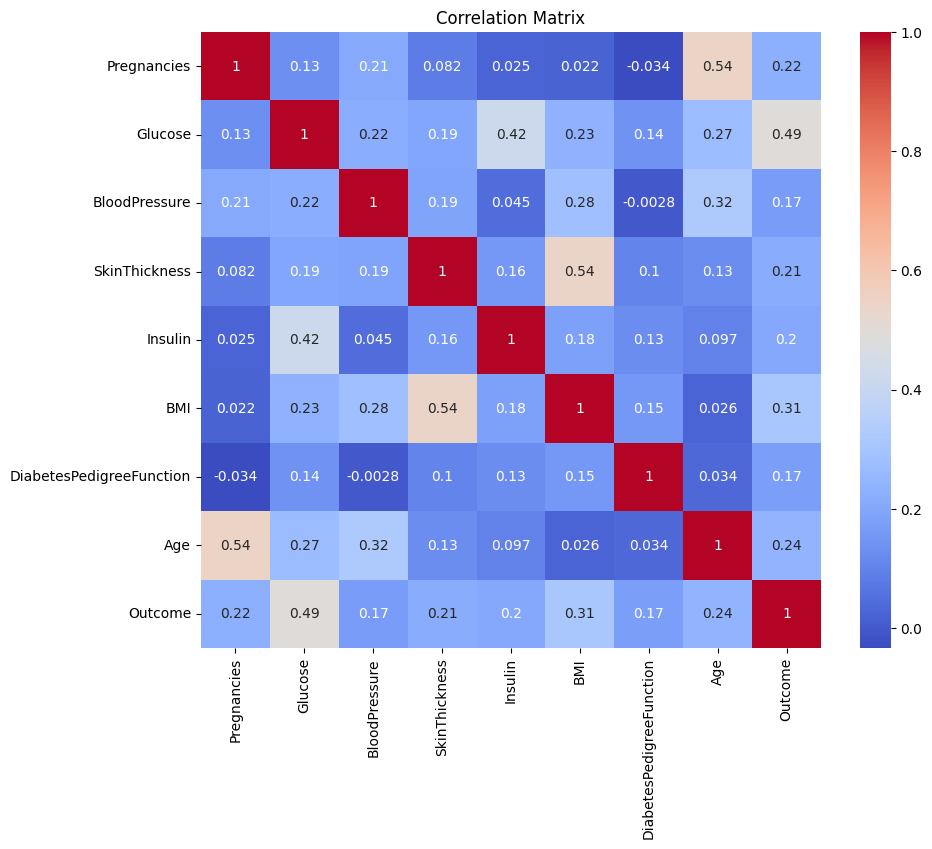

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


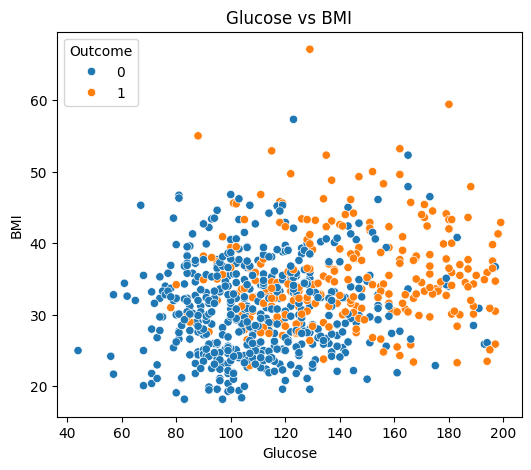

In [ ]:
# Scatter Plot
plt.figure(figsize=(6,5))
sns.scatterplot(x="Glucose",
                y="BMI",
                hue="Outcome",
                data=df)
plt.title("Glucose vs BMI")
plt.show()


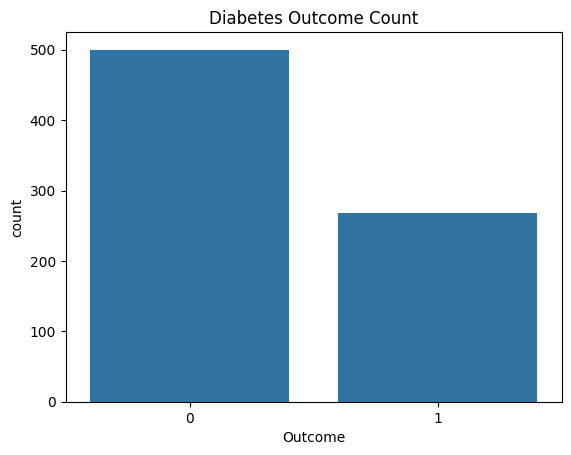

In [ ]:
# Bar Plot
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome Count")
plt.show()

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

lgbm = LGBMClassifier(random_state=42)

param_grid_lgb = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5,7]
}

grid_lgb = GridSearchCV(
    lgbm,
    param_grid_lgb,
    cv=5,
    scoring='accuracy'
)

grid_lgb.fit(X_train,y_train)

best_lgb = grid_lgb.best_estimator_

y_pred_lgb = best_lgb.predict(X_test)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

param_grid_xgb = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5,7]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring='accuracy'
)

grid_xgb.fit(X_train,y_train)

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)


 LightGBM
Accuracy : 0.7597402597402597
Precision: 0.6808510638297872
Recall   : 0.5925925925925926
F1 Score : 0.6336633663366337

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



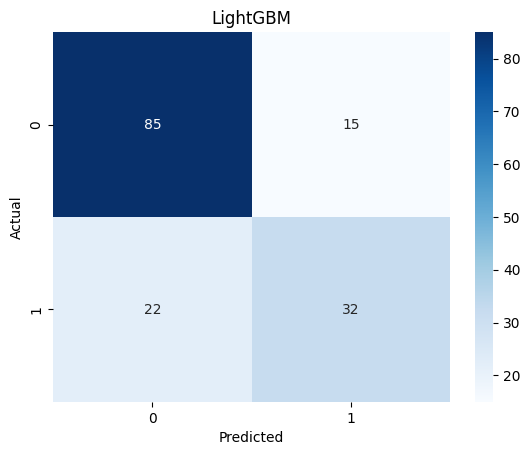


 XGBoost
Accuracy : 0.7597402597402597
Precision: 0.673469387755102
Recall   : 0.6111111111111112
F1 Score : 0.6407766990291263

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



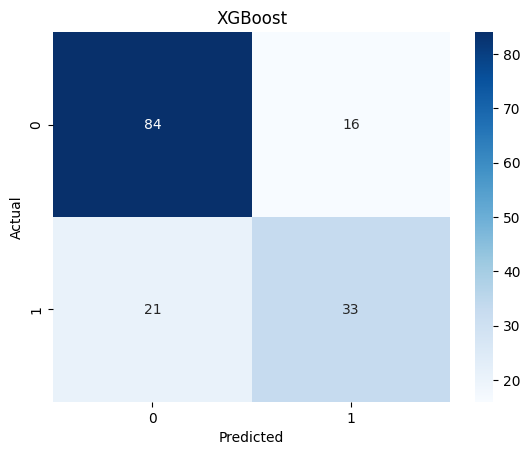

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate(name,y_true,y_pred):

    print("\n",name)

    print("Accuracy :",accuracy_score(y_true,y_pred))
    print("Precision:",precision_score(y_true,y_pred))
    print("Recall   :",recall_score(y_true,y_pred))
    print("F1 Score :",f1_score(y_true,y_pred))

    print("\nClassification Report")
    print(classification_report(y_true,y_pred))

    cm = confusion_matrix(y_true,y_pred)

    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues")

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

evaluate("LightGBM",y_test,y_pred_lgb)
evaluate("XGBoost",y_test,y_pred_xgb)

In [ ]:
from sklearn.model_selection import cross_val_score

lgb_cv = cross_val_score(best_lgb,
                         X,
                         y,
                         cv=5,
                         scoring='accuracy')

xgb_cv = cross_val_score(best_xgb,
                         X,
                         y,
                         cv=5,
                         scoring='accuracy')

print("\nLightGBM CV Accuracy:",lgb_cv.mean())
print("XGBoost CV Accuracy:",xgb_cv.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000164 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 669
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

      Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM   0.75974   0.680851  0.592593  0.633663
1   XGBoost   0.75974   0.673469  0.611111  0.640777


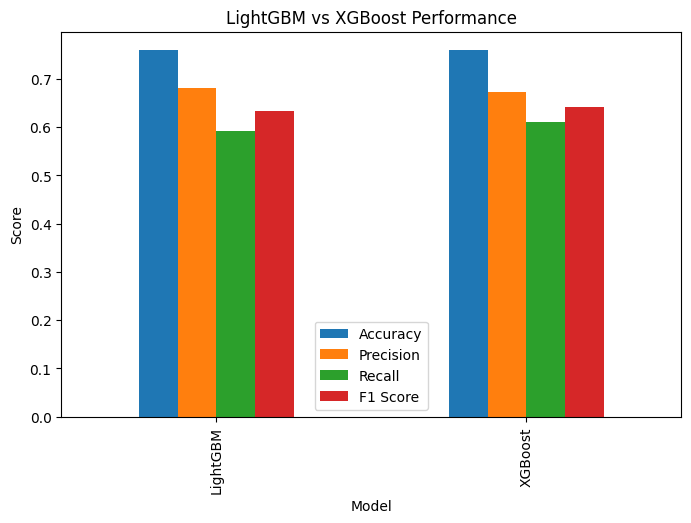

In [ ]:
results = pd.DataFrame({

    "Model":["LightGBM","XGBoost"],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lgb),
        accuracy_score(y_test,y_pred_xgb)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lgb),
        precision_score(y_test,y_pred_xgb)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lgb),
        recall_score(y_test,y_pred_xgb)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_lgb),
        f1_score(y_test,y_pred_xgb)
    ]

})

print(results)

results.set_index("Model").plot(kind="bar",
                                figsize=(8,5))

plt.title("LightGBM vs XGBoost Performance")
plt.ylabel("Score")
plt.show()

Conclusion

n this assignment, both LightGBM and XGBoost gave good results for predicting diabetes. XGBoost achieved slightly better accuracy, while LightGBM trained faster and required less computation time. Both algorithms are effective for this dataset, but if faster training is important, LightGBM is a better choice. If the goal is to achieve the highest possible accuracy, XGBoost is slightly better after hyperparameter tuning. Overall, both models are reliable and can be used for diabetes prediction.